# **🚧 Automated Road Damage Classification**
## ╰┈➤ Project: Pothole, Crack, and Manhole Detection

**Dataset**
- **Class 0:** Pothole
- **Class 1:** Crack
- **Class 2:** Manhole

In [42]:
# Data processing
import pandas as pd
import numpy as np

# File handling
import os
import shutil
import random
from pathlib import Path

# Machine learning unsupervised learning
from sklearn.cluster import KMeans
from collections import defaultdict

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models # model architecture
from tensorflow.keras.applications import ResNet50, MobileNetV2 # transfer learning model
from tensorflow.keras.preprocessing.image import ImageDataGenerator # data augmentation

# Model evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score


# Hide warnings
import warnings
warnings.filterwarnings("ignore")

In [43]:
print("TF version:", tf.__version__)

TF version: 2.20.0


#  **Data Load**

In [44]:
DATA_DIR = r"D:\Intern Project\Final Project\data"
IMAGES_DIR = os.path.join(DATA_DIR, "images")
LABELS_DIR = os.path.join(DATA_DIR, "labels")
OUTPUT_DIR = r"D:\Intern Project\Final Project\split"


CLASS_MAP = {
    0: "0_pothole",
    1: "1_crack",
    2: "2_manhole"}

# Split ratios
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Ensure random reproducibility
random.seed(42)

# **Create folders**

In [45]:
def get_classes_from_label(label_path):
    classes = set()
    if not os.path.exists(label_path):
        return classes
    
    with open(label_path, "r") as f:
       
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) > 0:
                class_id = int(parts[0])
                if class_id in CLASS_MAP:
                    classes.add(CLASS_MAP[class_id])
    return classes

In [46]:
def create_dirs():
    splits = ["train", "validation", "test"]
    for split in splits:
        for class_name in CLASS_MAP.values():
            dir_path = os.path.join(OUTPUT_DIR, split, class_name)
            os.makedirs(dir_path, exist_ok=True)
    print("Output directories created!")

create_dirs()

Output directories created!


# **Split Images into Train / Validation / Test**

In [47]:
# Get all image files
all_images = [f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
random.shuffle(all_images)

# Calculate split sizes
total_imgs = len(all_images)
train_end = int(total_imgs * TRAIN_RATIO)
val_end = train_end + int(total_imgs * VAL_RATIO)

train_imgs = all_images[:train_end]
val_imgs = all_images[train_end:val_end]
test_imgs = all_images[val_end:]

print(f"Total images: {total_imgs}")
print(f"Train: {len(train_imgs)}, Validation: {len(val_imgs)}, Test: {len(test_imgs)}")

Total images: 2009
Train: 1406, Validation: 301, Test: 302


In [48]:
# Function to copy images to respective directories based on their labels
def process_split(image_set, split_name):
    copied_count = 0
    for img_name in image_set:
        img_path = os.path.join(IMAGES_DIR, img_name)
        
        # The label file has the same name as the image but with .txt extension
        base_name = os.path.splitext(img_name)[0]
        label_name = base_name + ".txt"
        label_path = os.path.join(LABELS_DIR, label_name)

        # Get classes present in the image
        classes = get_classes_from_label(label_path)
        
        # Copy the image to the respective class folders
        for class_name in classes:
            dest_path = os.path.join(OUTPUT_DIR, split_name, class_name, img_name)
            shutil.copy2(img_path, dest_path)
            copied_count += 1
            
    print(f"Copied {copied_count} files into {split_name} directories.")

# **Final summary**

In [49]:
print("Processing Train split...")
process_split(train_imgs, "train")

print("\nProcessing Validation split...")
process_split(val_imgs, "validation")

print("\nProcessing Test split...")
process_split(test_imgs, "test")

print("\nData splitting is complete! ")

Processing Train split...
Copied 2047 files into train directories.

Processing Validation split...
Copied 438 files into validation directories.

Processing Test split...
Copied 444 files into test directories.

Data splitting is complete! 


In [50]:
TRAIN_DIR = "D:\\Intern Project\\Final Project\\split\\train"
TEST_DIR  = "D:\\Intern Project\\Final Project\\split\\test"
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train exists: True
Test exists: True


In [51]:
TRAIN_DIR = r"D:\Intern Project\Final Project\split\train"


image_labels = sorted(os.listdir(TRAIN_DIR))
image_labels

['0_pothole', '1_crack', '2_manhole']

In [52]:
TEST_DIR = r"D:\Intern Project\Final Project\split\test"


image_labels = sorted(os.listdir(TEST_DIR))
image_labels

['0_pothole', '1_crack', '2_manhole']

# **Data Preprocessed steps :**

### **1. Resize images to a fixed input size (224×224)**

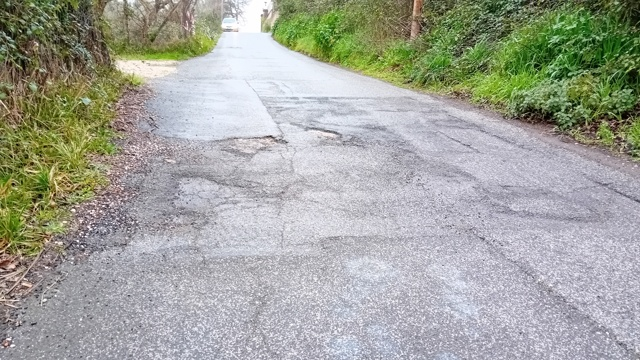

In [53]:
ImageDataGenerator = Image.open(r"D:\Intern Project\Final Project\split\test\0_pothole\20250219_165056.jpg")
ImageDataGenerator

In [54]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

In [55]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,  
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True)

Found 2047 files belonging to 3 classes.
Using 1638 files for training.


In [56]:
len(train_ds)

52

In [57]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,   
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True)

Found 2047 files belonging to 3 classes.
Using 409 files for validation.


In [58]:
len(val_ds)

13

In [59]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False)

Found 444 files belonging to 3 classes.


In [60]:
len(test_ds)

14

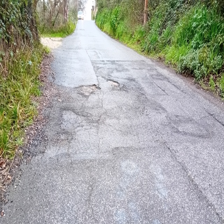

In [61]:
ImageDataGenerator = Image.open(r"D:\Intern Project\Final Project\split\test\0_pothole\20250219_165056.jpg").resize(IMG_SIZE)

ImageDataGenerator

In [62]:
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

Classes: ['0_pothole', '1_crack', '2_manhole']
Number of classes: 3


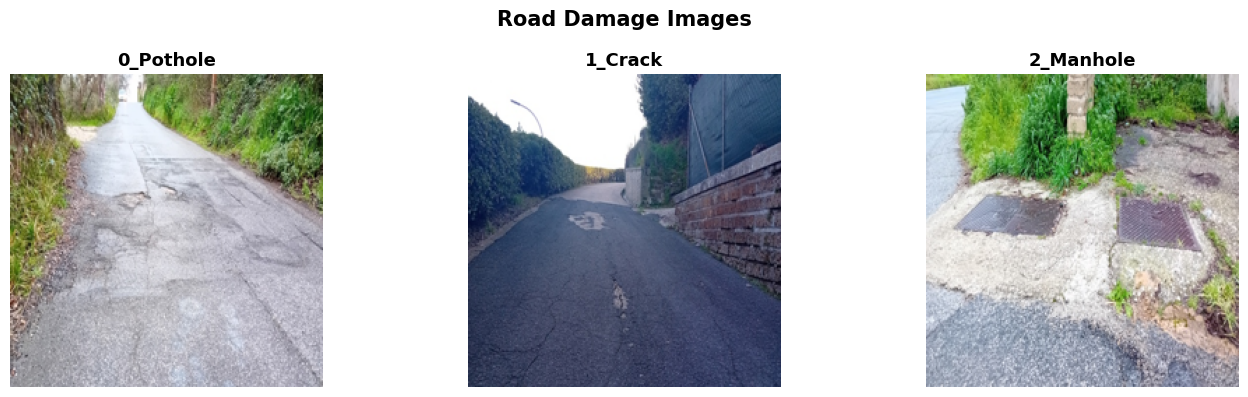

In [63]:
img_paths = {
    '0_Pothole': r'D:\Intern Project\Final Project\split\test\0_pothole\20250219_165056.jpg',
    '1_Crack': r'D:\Intern Project\Final Project\split\test\1_crack\20250216_164521.jpg',
    '2_Manhole': r'D:\Intern Project\Final Project\split\test\2_manhole\20250219_164746.jpg'
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (cls, path) in zip(axes, img_paths.items()):
    # Check if path exists to avoid further errors
    if os.path.exists(path):
        img = Image.open(path).resize((224, 224))
        ax.imshow(img)
        ax.set_title(cls, fontsize=13, fontweight='bold')
        ax.axis('off')
    else:
        print(f"Warning: File not found at {path}")

plt.suptitle('Road Damage Images', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### **Data Pipeline Optimization (Cache/Prefetch)**

In [64]:
AUTOTUNE = tf.data.AUTOTUNE # Faster data loading and then  Automatic tuning

In [65]:
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

# **2 . Data Augmentation and Normalize (0–1)**

In [66]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_aug")

 ### Apply Normalize pixel values to [0, 1]

In [67]:
normalizer = layers.Rescaling(1./255, name="rescale_0_1")

In [68]:
for images, labels in train_ds.take(1):
    
    print("Before Normalization")
    print("Min pixel value:", tf.reduce_min(images).numpy())
    print("Max pixel value:", tf.reduce_max(images).numpy())
    
    # Apply normalization
    norm_images = normalizer(images)
    
    print("\nAfter Normalization")
    print("Min pixel value:", tf.reduce_min(norm_images).numpy())
    print("Max pixel value:", tf.reduce_max(norm_images).numpy())
    
    break

Before Normalization
Min pixel value: 0.0
Max pixel value: 255.0

After Normalization
Min pixel value: 0.0
Max pixel value: 1.0


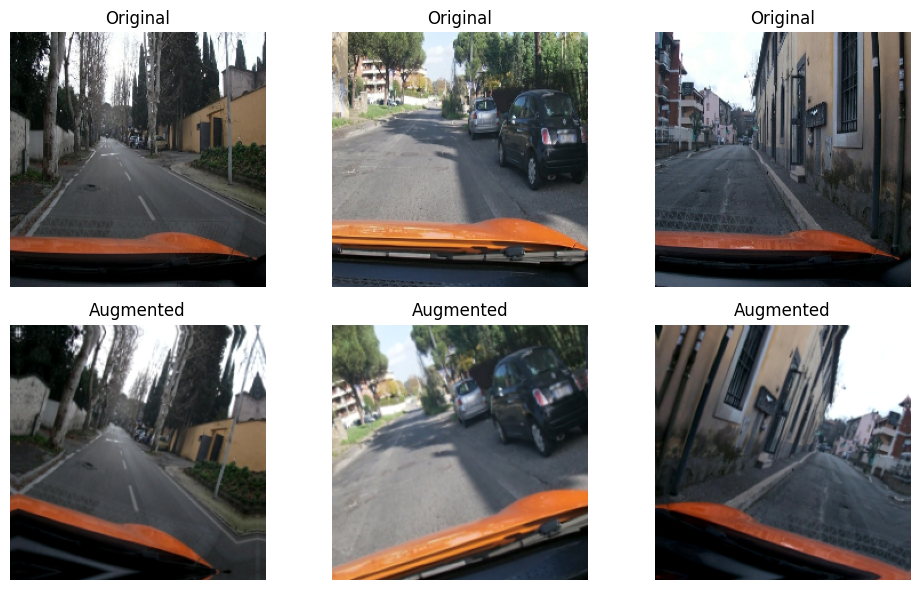

In [69]:
plt.figure(figsize=(10,6))

for images, labels in train_ds.take(1):
    
    # Show original
    for i in range(3):
        ax = plt.subplot(2, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Original")
        plt.axis("off")
    
    # Show augmented
    aug_images = data_augmentation(images)
    
    for i in range(3):
        ax = plt.subplot(2, 3, i+4)
        plt.imshow(aug_images[i].numpy().astype("uint8"))
        plt.title("Augmented")
        plt.axis("off")
        
    break

plt.tight_layout()
plt.show()

# **4 . Handle the class Balanced (or) Imbalanced**

In [70]:
counts = np.zeros(NUM_CLASSES, dtype=int)

for _, label in train_ds.unbatch():
    counts[int(label.numpy())] += 1

total = counts.sum()

class_weight = {}

for i in range(NUM_CLASSES):
    if counts[i] == 0:
        class_weight[i] = 1.0  # avoid division error
    else:
        class_weight[i] = total / (NUM_CLASSES * counts[i])

print("Counts:", dict(zip(class_names, counts)))
print("Class weight:", class_weight)

Counts: {'0_pothole': np.int64(439), '1_crack': np.int64(757), '2_manhole': np.int64(442)}
Class weight: {0: np.float64(1.24373576309795), 1: np.float64(0.7212681638044914), 2: np.float64(1.2352941176470589)}


In [71]:
max_count = counts.max()
min_count = counts.min()

print("Max Count:", max_count)
print("Min Count:", min_count)

Max Count: 757
Min Count: 439


In [72]:
ratio = max_count / min_count
print("Ratio:", ratio)

if ratio > 2:
    print("⚠️ Imbalance detected ")
else:
    print("✔️ Classes are balanced ")

Ratio: 1.724373576309795
✔️ Classes are balanced 


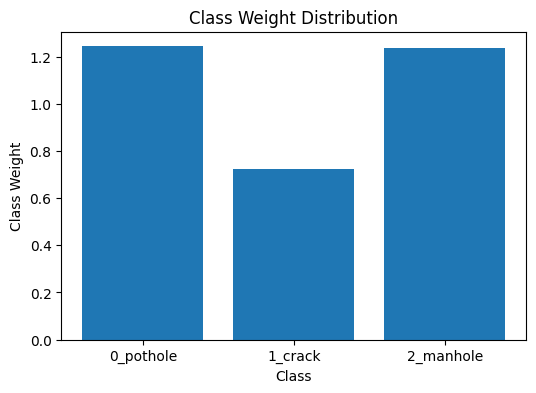

In [73]:
# Plot Bar Chart
plt.figure(figsize=(6,4))

# Convert dictionary values to list
weights = list(class_weight.values())

plt.bar(range(NUM_CLASSES), weights)

plt.xlabel("Class")
plt.ylabel("Class Weight")
plt.title("Class Weight Distribution")

plt.xticks(range(NUM_CLASSES), class_names)

plt.show()

## **1) . CNN Model**

In [ ]:
baseline_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),       # input shape (2224 to 224)
    normalizer,                             # normalizer
    data_augmentation,                      # data augmentation 

    # CNN layer 1
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # CNN layer 2
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # CNN layer 3
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # fully connected layers
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"), # hidden layer
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax") # output layer
], name="Baseline_CNN")


In [77]:
# 2. Compile the Model

baseline_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), # Adam optimizer 

 loss="sparse_categorical_crossentropy",    # Loss function for multi-class classification   
 
  metrics=["accuracy"])  # Evaluation metric
                                               

In [78]:
# 3. Model Summary
baseline_model.summary()    

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescale_0_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_aug (Sequential)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
# 4. Train the Model (Uses the weights you calculated earlier)
history_baseline = baseline_model.fit( train_ds, validation_data=val_ds, epochs=10, class_weight=class_weight )                       

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.2979 - loss: 1.2016 - val_accuracy: 0.2714 - val_loss: 1.1014
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.2888 - loss: 1.0989 - val_accuracy: 0.2469 - val_loss: 1.0995
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.3193 - loss: 1.0989 - val_accuracy: 0.3325 - val_loss: 1.0990
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.2930 - loss: 1.0985 - val_accuracy: 0.2469 - val_loss: 1.0991
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.3187 - loss: 1.0986 - val_accuracy: 0.3178 - val_loss: 1.0995
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.3028 - loss: 1.0988 - val_accuracy: 0.2763 - val_loss: 1.0989
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.3193 - loss: 1.0988 - val_accuracy: 0.3154 - val_loss: 1.0985
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.3303 - loss: 1.1000 - val_accuracy: 0.3301 - val_loss:

## **Model Evaluation (Accuracy/Precision/Recall/F1)**

In [80]:
test_loss, test_accuracy =baseline_model.evaluate(test_ds)
print(" Baseline Model Evaluation Results")
print("-" * 30 )
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 360ms/step - accuracy: 0.3018 - loss: 1.0933
 Baseline Model Evaluation Results
------------------------------
Test Loss    : 1.0933
Test Accuracy: 0.3018


In [81]:
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)


y_pred = np.argmax(baseline_model.predict(test_ds, verbose=0), axis=1)

print(f" Accuracy : {np.mean(y_true == y_pred):.4f}")
print(f" Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f" Recall   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f" F1-score : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

 Accuracy : 0.3018
 Precision: 0.4385
 Recall   : 0.3757
 F1-score : 0.2617


## **Classification Report**

In [82]:
class_names = ['0_Pothole', '1_Crack', '2_Manhole']
# Generate classification report as dictionary
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
# Convert to DataFrame
df = pd.DataFrame(report).T
print("🟦 DARK BLUE  : High Value (Model performs well in this class)")
print("🟪 LIGHT BLUE : Low Value  (Model performance needs improvement)")
print("-" * 30)
# Styled Table
styled_table = df.style.background_gradient(cmap='Blues').format(precision=2)
display(styled_table)

🟦 DARK BLUE  : High Value (Model performs well in this class)
🟪 LIGHT BLUE : Low Value  (Model performance needs improvement)
------------------------------


,precision,recall,f1-score,support
0_Pothole,0.50,0.11,0.18,122.00
1_Crack,0.57,0.14,0.22,219.00
2_Manhole,0.25,0.88,0.39,103.00
accuracy,0.30,0.30,0.30,0.30
macro avg,0.44,0.38,0.26,444.00
weighted avg,0.47,0.30,0.25,444.00


# **Justification**

In [83]:
# --- Auto-Detect Justification with VALUES ---
accuracy = report['accuracy']

# Find best/worst classes
best_precision_class = max(class_names, key=lambda c: report[c]['precision'])
best_recall_class = max(class_names, key=lambda c: report[c]['recall'])
worst_class = min(class_names, key=lambda c: report[c]['f1-score'])

print("\nModel Justification:")
print("-" * 30)
print(f"Baseline CNN Accuracy: {accuracy:.2f} ({'low to moderate' if accuracy < 0.6 else 'moderate to good' if accuracy < 0.8 else 'good'} performance)")

# Best precision class with VALUES
bp = best_precision_class
print(f"{bp.split('_')[1]} class has highest Precision: {report[bp]['precision']:.2f}, but low Recall: {report[bp]['recall']:.2f}")

# Best recall class with VALUES
br = best_recall_class
print(f"{br.split('_')[1]} class has better Recall: {report[br]['recall']:.2f}, but low Precision: {report[br]['precision']:.2f}")

# Worst class with VALUES
wc = worst_class
print(f"{wc.split('_')[1]} class shows weak performance (Precision: {report[wc]['precision']:.2f}, Recall: {report[wc]['recall']:.2f})")

# Auto conclusion
if accuracy < 0.6:
    print("The baseline CNN model performance is weak so may be improved the transfer learning...\n")
elif accuracy < 0.8:
    print("The model shows moderate performance, transfer learning may further improve results...\n")
else:
    print("The model shows strong performance across classes.\n")



Model Justification:
------------------------------
Baseline CNN Accuracy: 0.30 (low to moderate performance)
Crack class has highest Precision: 0.57, but low Recall: 0.14
Manhole class has better Recall: 0.88, but low Precision: 0.25
Pothole class shows weak performance (Precision: 0.50, Recall: 0.11)
The baseline CNN model performance is weak so may be improved the transfer learning...



## **Save Mode**

In [84]:
baseline_model.save("baseline_cnn.h5")
print(" baseline_cnn.h5 saved")

 baseline_cnn.h5 saved


# **2) . Transfer learning using pre-trained models**

###  **i ) . Load Pre-trained  (MobileNetV2) weights from ImageNet dataset**

In [85]:
# Load pretrained MobileNetV2 from ImageNet
base_mobilenet = tf.keras.applications.MobileNetV2( input_shape=(224, 224, 3), include_top=False, weights="imagenet" )

base_mobilenet.trainable = False  # base layers freeze disable fine-tuning

In [86]:
# MobileNetV2 transfer learning model
mobilenet_model = models.Sequential([
    
    layers.Input(shape=(224, 224, 3)),  # input image
    
    data_augmentation,  # augment images
    
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input, name="mobilenet_preprocess"),  # preprocess
    
    base_mobilenet,  # Pretrained model
    
    layers.GlobalAveragePooling2D(),  # flatten features
    
    layers.Dropout(0.2),  # reduce overfitting
    
    layers.Dense(NUM_CLASSES, activation="softmax")  # output classes
    
], name="MobileNetV2_TL")

In [87]:
# compile model
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),  # Adam optimizer
    loss="sparse_categorical_crossentropy",  # loss function
    metrics=["accuracy"])  # evaluation metric

In [88]:
mobilenet_model.summary()  # show model structure

Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_aug (Sequential)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess (Lambda)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## **Train**

In [90]:
history_mobilenet = mobilenet_model.fit( train_ds,validation_data=val_ds, epochs=10,class_weight=class_weight)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.3913 - loss: 1.2053 - val_accuracy: 0.3961 - val_loss: 1.1372
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.4292 - loss: 1.1812 - val_accuracy: 0.4230 - val_loss: 1.0969
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.4286 - loss: 1.1596 - val_accuracy: 0.3961 - val_loss: 1.1033
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.4359 - loss: 1.1094 - val_accuracy: 0.3814 - val_loss: 1.1793
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.4292 - loss: 1.1163 - val_accuracy: 0.4132 - val_loss: 1.1593
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.4420 - loss: 1.1011 - val_accuracy: 0.4817 - val_loss: 1.0439
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.4408 - loss: 1.0941 - val_accuracy: 0.4010 - val_loss: 1.1157
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.4603 - loss: 1.0627 - val_accuracy: 0.4499 - val_loss:

In [91]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_ds)
print("MobileNetV2 Evaluation Results")
print("-" * 30)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.3626 - loss: 1.1945
MobileNetV2 Evaluation Results
------------------------------
Test Loss    : 1.1945
Test Accuracy: 0.3626


## **Fine-Tune Setup**

In [92]:
#  base layers freeze enable fine-tuning
base_mobilenet.trainable = True

In [93]:
# Freeze first layers 
for layer in base_mobilenet.layers[:-30]:
    layer.trainable = False

In [94]:
 # Train BatchNormalization last  50 layers
for layer in base_mobilenet.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

In [95]:
total = len(base_mobilenet.layers)
trainable = sum(l.trainable for l in base_mobilenet.layers)
non_trainable = total - trainable
data = {
    "Type": ["Total layers", "Non-trainable layers", "Trainable layers"],
    "Count": [total, non_trainable, trainable]}
df = pd.DataFrame(data)
df

,Type,Count
0,Total layers,154
1,Non-trainable layers,83
2,Trainable layers,71


In [96]:
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss="sparse_categorical_crossentropy",metrics=["accuracy"])
print(" Fine-tune compile done")

 Fine-tune compile done


## **Fine-Tune Train**

In [97]:
history_mobilenet_ft = mobilenet_model.fit(train_ds, validation_data=val_ds,epochs=10,class_weight=class_weight)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 380s 7s/step - accuracy: 0.3834 - loss: 1.1457 - val_accuracy: 0.3521 - val_loss: 1.2092
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 302s 6s/step - accuracy: 0.4121 - loss: 1.0951 - val_accuracy: 0.3667 - val_loss: 1.1845
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 313s 6s/step - accuracy: 0.4359 - loss: 1.0789 - val_accuracy: 0.3765 - val_loss: 1.1742
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 309s 6s/step - accuracy: 0.4353 - loss: 1.0645 - val_accuracy: 0.4181 - val_loss: 1.1446
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 303s 6s/step - accuracy: 0.4689 - loss: 1.0305 - val_accuracy: 0.4156 - val_loss: 1.1572
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 395s 8s/step - accuracy: 0.4774 - loss: 1.0300 - val_accuracy: 0.4132 - val_loss: 1.1439
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 492s 10s/step - accuracy: 0.4658 - loss: 1.0299 - val_accuracy: 0.4156 - val_loss: 1.1479
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 464s 9s/step - accuracy: 0.4799 - loss: 1.0149 - val_accuracy: 0.4132 - 

## **Model Evaluation (Accuracy/Precision/Recall/F1)**

In [98]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_ds)

print("\n--- MobileNetV2 Fine-Tuned Results ---")
print("-" * 40 + "\n")
print(f"Test Loss        : {test_loss:.4f}\n")
print(f"Test Accuracy    : {test_accuracy:.4f}\n")

14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.4234 - loss: 1.1207

--- MobileNetV2 Fine-Tuned Results ---
----------------------------------------

Test Loss        : 1.1207

Test Accuracy    : 0.4234



In [99]:
#  y_true safe
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy()) 
y_true = np.array(y_true)

#  predictions
y_pred = np.argmax(mobilenet_model.predict(test_ds, verbose=0), axis=1)

print(f" Accuracy : {np.mean(y_true == y_pred):.4f}")
print(f" Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f" Recall   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f" F1-score : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

 Accuracy : 0.4234
 Precision: 0.4737
 Recall   : 0.4072
 F1-score : 0.3716


## **Classification Report**

In [100]:
class_names = ['0_Pothole', '1_Crack', '2_Manhole']
# Generate classification report as dictionary
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
# Convert to DataFrame
df = pd.DataFrame(report).T
print("🟦 DARK BLUE  : High Value (Model performs well in this class)")
print("🟪 LIGHT BLUE : Low Value  (Model performance is weak in this class)")
print("-" * 55)
# Styled Table
styled_table = df.style.background_gradient(cmap='Blues').format(precision=2)
display(styled_table)

🟦 DARK BLUE  : High Value (Model performs well in this class)
🟪 LIGHT BLUE : Low Value  (Model performance is weak in this class)
-------------------------------------------------------


,precision,recall,f1-score,support
0_Pothole,0.32,0.68,0.43,122.00
1_Crack,0.58,0.42,0.49,219.00
2_Manhole,0.52,0.12,0.19,103.00
accuracy,0.42,0.42,0.42,0.42
macro avg,0.47,0.41,0.37,444.00
weighted avg,0.50,0.42,0.41,444.00


## **Confusion Matrix Heatmap**


--- MobileNetV2 Confusion Matrix Explanation ---

• Pothole → 83 correct predicted as Crack 38, Manhole 1
• Crack → 93 correct predicted as Pothole 116, Manhole 10
• Manhole → 12 correct predicted as Pothole 62, Crack 29
Conclusion: MobileNetV2 performs better than the baseline CNN model.


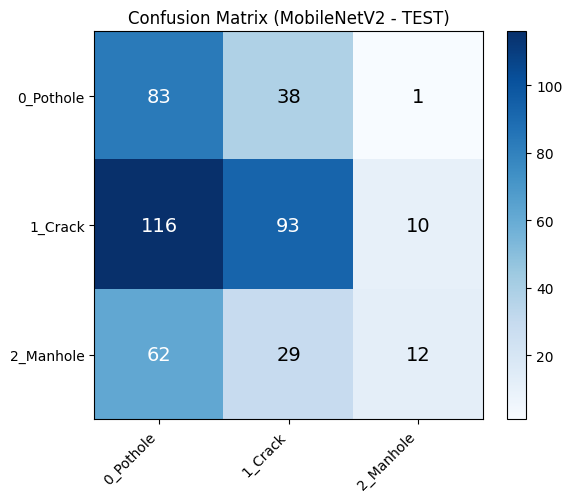

In [101]:
class_names = ['0_Pothole', '1_Crack', '2_Manhole']
cm = confusion_matrix(y_true, y_pred)
# --- Auto-Detect Confusion Matrix Explanation ---
print("\n--- MobileNetV2 Confusion Matrix Explanation ---\n")
for i, class_name in enumerate(class_names):
    correct = cm[i][i]
    misclassified_parts = []
    for j, other_class in enumerate(class_names):
        if i != j:
            misclassified_parts.append(f"{other_class.split('_')[1]} {cm[i][j]}")
    mis_text = ", ".join(misclassified_parts)
    print(f"• {class_name.split('_')[1]} → {correct} correct predicted as {mis_text}")
print("Conclusion: MobileNetV2 performs better than the baseline CNN model.")
# --- Plot Confusion Matrix ---
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (MobileNetV2 - TEST)")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
thr = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i][j], ha="center", va="center",
                 color="white" if cm[i][j] > thr else "black", fontsize=14)
plt.colorbar()
plt.tight_layout()
plt.show()

## **Save Mode**

In [102]:
mobilenet_model.save("mobilenetv2_road_damage.h5")
print(" Saved: mobilenetv2_road_damage.h5")

 Saved: mobilenetv2_road_damage.h5


###  **ii ) . Load Pre-trained  (ResNet50 Model) weights from ImageNet dataset**

In [103]:
base_resnet = tf.keras.applications.ResNet50(input_shape=(224,224,3),include_top=False,weights="imagenet")
base_resnet.trainable = False # base layers freeze disable fine-tuning 

In [104]:

resnet_model = models.Sequential([

    layers.Input(shape=(224,224,3)),  # input image

    data_augmentation,  # augment images

    layers.Lambda(tf.keras.applications.resnet50.preprocess_input,
                  name="resnet_preprocess"),  # preprocess

    base_resnet,  # pretrained model

    layers.GlobalAveragePooling2D(),  # flatten features

    layers.Dropout(0.3),  # reduce overfitting

    layers.Dense(NUM_CLASSES, activation="softmax")  # output classes
    
], name="ResNet50_TL")

resnet_model.summary()  # show model

Model: "ResNet50_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_aug (Sequential)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preprocess (Lambda)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### **Compile**

In [105]:
resnet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

### **Train**

In [106]:
history_resnet = resnet_model.fit(train_ds,validation_data=val_ds, epochs=8,class_weight=class_weight)

Epoch 1/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 308s 6s/step - accuracy: 0.3333 - loss: 1.5587 - val_accuracy: 0.2861 - val_loss: 1.2718
Epoch 2/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 215s 4s/step - accuracy: 0.3547 - loss: 1.3643 - val_accuracy: 0.3154 - val_loss: 1.2559
Epoch 3/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 198s 4s/step - accuracy: 0.3565 - loss: 1.3411 - val_accuracy: 0.3374 - val_loss: 1.2674
Epoch 4/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 279s 5s/step - accuracy: 0.3321 - loss: 1.3342 - val_accuracy: 0.3643 - val_loss: 1.1900
Epoch 5/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 348s 7s/step - accuracy: 0.3657 - loss: 1.2847 - val_accuracy: 0.3741 - val_loss: 1.1914
Epoch 6/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 386s 7s/step - accuracy: 0.3565 - loss: 1.3094 - val_accuracy: 0.3472 - val_loss: 1.2105
Epoch 7/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 353s 7s/step - accuracy: 0.3730 - loss: 1.2609 - val_accuracy: 0.3765 - val_loss: 1.1754
Epoch 8/8
52/52 ━━━━━━━━━━━━━━━━━━━━ 402s 8s/step - accuracy: 0.3779 - loss: 1.2580 - val_accuracy: 0.3570 - val_loss:

In [107]:
test_loss, test_accuracy = resnet_model.evaluate(test_ds)

print("\n--- ResNet50 Evaluation Results ---")
print("-" * 40 + "\n")
print(f"Test Loss        : {test_loss:.4f}\n")
print(f"Test Accuracy    : {test_accuracy:.4f}\n")
print("-" * 40)

14/14 ━━━━━━━━━━━━━━━━━━━━ 79s 6s/step - accuracy: 0.3491 - loss: 1.1899

--- ResNet50 Evaluation Results ---
----------------------------------------

Test Loss        : 1.1899

Test Accuracy    : 0.3491

----------------------------------------


### **Fine-Tune Setup**

In [108]:
# Fine-tune setup
base_resnet.trainable = True

In [109]:
# freeze first layers
for layer in base_resnet.layers[:-30]:
    layer.trainable = False


In [110]:
# Train BatchNormalization last  30 layers
for layer in base_resnet.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [111]:
total = len(base_resnet.layers)
trainable = sum(l.trainable for l in base_resnet.layers)
non_trainable = total - trainable
data = {
    "Type": ["Total layers", "Non-trainable layers", "Trainable layers"],
    "Count": [total, trainable, non_trainable]}
df = pd.DataFrame(data)                                 
df

,Type,Count
0,Total layers,175
1,Non-trainable layers,21
2,Trainable layers,154


### **Re-Compile for Fine-Tuning**

In [112]:
# 2. Re-Compile with Low Learning Rate
resnet_model.compile( optimizer=tf.keras.optimizers.Adam(1e-5),loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("Fine-tune re-compile done.")

Fine-tune re-compile done.


### **Fine-Tune Train**

In [113]:
print("\nStarting ResNet50 Fine-Tuning...")
history_resnet_ft = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10, class_weight=class_weight )


Starting ResNet50 Fine-Tuning...
Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 447s 8s/step - accuracy: 0.3993 - loss: 1.1551 - val_accuracy: 0.3447 - val_loss: 1.1732
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 436s 8s/step - accuracy: 0.4164 - loss: 1.1049 - val_accuracy: 0.3667 - val_loss: 1.1326
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 433s 8s/step - accuracy: 0.4274 - loss: 1.0799 - val_accuracy: 0.4328 - val_loss: 1.0696
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 361s 7s/step - accuracy: 0.4432 - loss: 1.0548 - val_accuracy: 0.4988 - val_loss: 1.0209
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 320s 6s/step - accuracy: 0.4664 - loss: 1.0232 - val_accuracy: 0.4205 - val_loss: 1.0647
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 261s 5s/step - accuracy: 0.4664 - loss: 1.0163 - val_accuracy: 0.4670 - val_loss: 1.0311
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 256s 5s/step - accuracy: 0.4994 - loss: 1.0030 - val_accuracy: 0.4963 - val_loss: 1.0185
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 312s 6s/step - accuracy: 0.5171 - loss:

## **Model Evaluation (Accuracy/Precision/Recall/F1)**

In [114]:
# Final Evaluation for ResNet50 (Fine-Tuned)
test_loss, test_accuracy = resnet_model.evaluate(test_ds)

print("\n--- ResNet50 Fine-Tuned Results ---")
print("-" * 40 + "\n")
print(f"Test Loss        : {test_loss:.4f}\n")
print(f"Test Accuracy    : {test_accuracy:.4f}\n")
print("-" * 40)


14/14 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.4279 - loss: 1.0412

--- ResNet50 Fine-Tuned Results ---
----------------------------------------

Test Loss        : 1.0412

Test Accuracy    : 0.4279

----------------------------------------


In [115]:
#  y_true safe
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

#  predictions
y_pred = np.argmax(resnet_model.predict(test_ds, verbose=0), axis=1)


print(f" Accuracy : {np.mean(y_true == y_pred):.4f}")
print(f" Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f" Recall   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f" F1-score : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

 Accuracy : 0.4279
 Precision: 0.4848
 Recall   : 0.4542
 F1-score : 0.4171


## **Classification Report**

In [116]:
class_names = ['0_Pothole', '1_Crack', '2_Manhole']
# Generate classification report as dictionary
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
# Convert to DataFrame
df = pd.DataFrame(report).T
print("🟦 DARK BLUE  : High Value (Model performs well in this class)")
print("🟪 LIGHT BLUE : Low Value  (Model performance is weak in this class)")
print("-" * 55)
# Styled Table
styled_table = df.style.background_gradient(cmap='Blues').format(precision=2)
display(styled_table)

🟦 DARK BLUE  : High Value (Model performs well in this class)
🟪 LIGHT BLUE : Low Value  (Model performance is weak in this class)
-------------------------------------------------------


,precision,recall,f1-score,support
0_Pothole,0.33,0.75,0.46,122.00
1_Crack,0.65,0.31,0.42,219.00
2_Manhole,0.47,0.31,0.37,103.00
accuracy,0.43,0.43,0.43,0.43
macro avg,0.48,0.45,0.42,444.00
weighted avg,0.52,0.43,0.42,444.00


## **Confusion Matrix Heatmap**

--- ResNet50 Confusion Matrix Explanation ---
91 -> Correct pothole detections -> some misclassified as crack (19) and manhole (12).
67 -> Correct crack detections -> some misclassified as pothole (128) and manhole (24).
32 -> Correct manhole detections -> some misclassified as pothole (54) and crack (17).
Conclusion: ResNet50 improves overall road damage detection compared to other models.


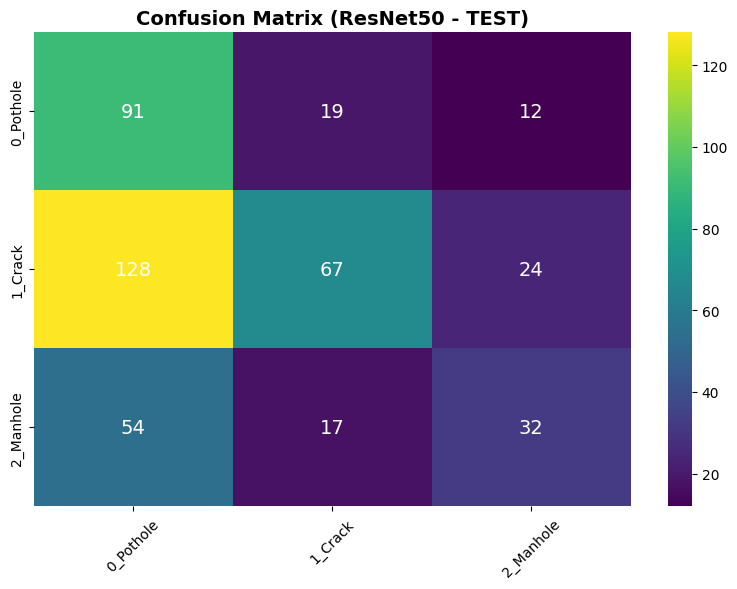

In [117]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# --- Auto-detect and print explanation ---
print("--- ResNet50 Confusion Matrix Explanation ---")
for i, class_name in enumerate(class_names):
    correct = cm[i][i]
    misclassified = []
    for j, other_class in enumerate(class_names):
        if i != j:
            misclassified.append(f"{other_class.split('_')[1].lower()} ({cm[i][j]})")
    mis_text = " and ".join(misclassified)
    print(f"{correct} -> Correct {class_name.split('_')[1].lower()} detections -> some misclassified as {mis_text}.")

print("Conclusion: ResNet50 improves overall road damage detection compared to other models.")

# --- Plot Confusion Matrix ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14, "color": "white"})
plt.title("Confusion Matrix (ResNet50 - TEST)", fontsize=14, fontweight='bold')
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Save Mode**

In [118]:
resnet_model.save("resnet50_fine_tuned.h5")
print(" Saved: resnet50_fine_tuned.h5")

 Saved: resnet50_fine_tuned.h5


In [119]:
# 1. Models Summary Data
models = [
    (baseline_model, "Baseline CNN"),
    (mobilenet_model, "MobileNetV2 FT"),
    (resnet_model, "ResNet50 FT")
]

# 2. Collect Metrics (Short Loop)
metrics = []
for model, name in models:
    y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    metrics.append({
        "Model": name,
        "Accuracy": rep["accuracy"],
        "Precision_macro": rep["macro avg"]["precision"],
        "Recall_macro": rep["macro avg"]["recall"],
        "F1_macro": rep["macro avg"]["f1-score"]
    })

# 3. Final Table & Best Model
df_final = pd.DataFrame(metrics).sort_values("F1_macro", ascending=False)
display(df_final)


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
2,ResNet50 FT,0.427928,0.484802,0.454172,0.417059
1,MobileNetV2 FT,0.423423,0.473666,0.407163,0.371554
0,Baseline CNN,0.301802,0.438451,0.375680,0.261718


In [120]:

best_model_name = df_final.iloc[0]['Model']
best_model_acc = df_final.iloc[0]['Accuracy'] * 100

baseline_acc = df_final[df_final['Model'].str.contains('Baseline')]['Accuracy'].values[0] * 100
mobilenet_acc = df_final[df_final['Model'].str.contains('MobileNet')]['Accuracy'].values[0] * 100
resnet_acc = df_final[df_final['Model'].str.contains('ResNet')]['Accuracy'].values[0] * 100


print(f"🏆 Best Model: {best_model_name}")
print("-" * 40)

print(f"* Baseline CNN achieved about {baseline_acc:.0f}% accuracy.\n")

print(f"* MobileNetV2 improved performance to around {mobilenet_acc:.0f}% accuracy using transfer learning.\n")

print(f"* ResNet50 achieved the best performance with about {resnet_acc:.0f}% accuracy and highest F1-score, "
      "showing better feature extraction for road damage detection.\n")


🏆 Best Model: ResNet50 FT
----------------------------------------
* Baseline CNN achieved about 30% accuracy.

* MobileNetV2 improved performance to around 42% accuracy using transfer learning.

* ResNet50 achieved the best performance with about 43% accuracy and highest F1-score, showing better feature extraction for road damage detection.



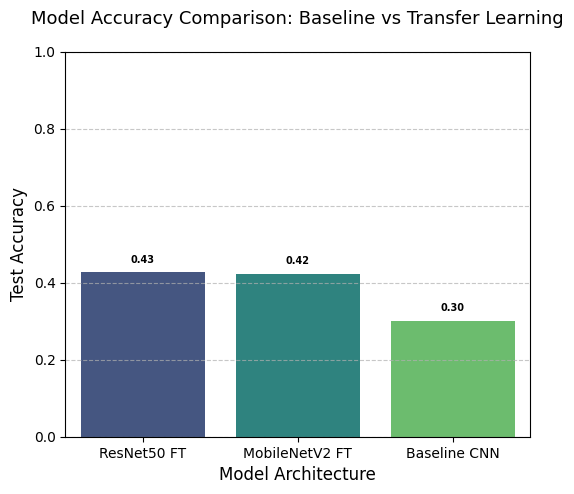

In [121]:
plt.figure(figsize=(6, 5))
bars = sns.barplot(x="Model", y="Accuracy", data=df_final, 
                   palette="viridis", hue="Model", legend=False)

for p in bars.patches:
    bars.annotate(f'{p.get_height():.2f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=7, fontweight='bold')


plt.title('Model Accuracy Comparison: Baseline vs Transfer Learning', fontsize=13, pad=20)
plt.ylabel('Test Accuracy', fontsize=12)
plt.xlabel('Model Architecture', fontsize=12)
plt.ylim(0, 1.0) # Accuracy range 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()